In [1]:
import numpy as np
import warnings
import os
import sys
from scipy.optimize import fsolve, brentq
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
import seaborn as sns

import pandas as pd
from numpy.linalg import norm
from joblib import Parallel, delayed
import time
import h5py

sys.path.append('../models')
from traditional_npz import npz_nl, rk4, run_rk4_for_initial_conditions, npz_tl, rk4_tl, npz_ad, rk4_ad
sys.path.append('../utils')
from additional_files import calculate_rel_error, calculate_rmse, sample_npz_uniformN_dirichletPZ, embedded_npz, calculate_fixed_points


In [2]:
# --- Example usage ---
np.random.seed(1234)
num_states = 500_000
npz_matrix_simplex = sample_npz_uniformN_dirichletPZ(n_samples=num_states)
print(npz_matrix_simplex.shape)


(500000, 3)


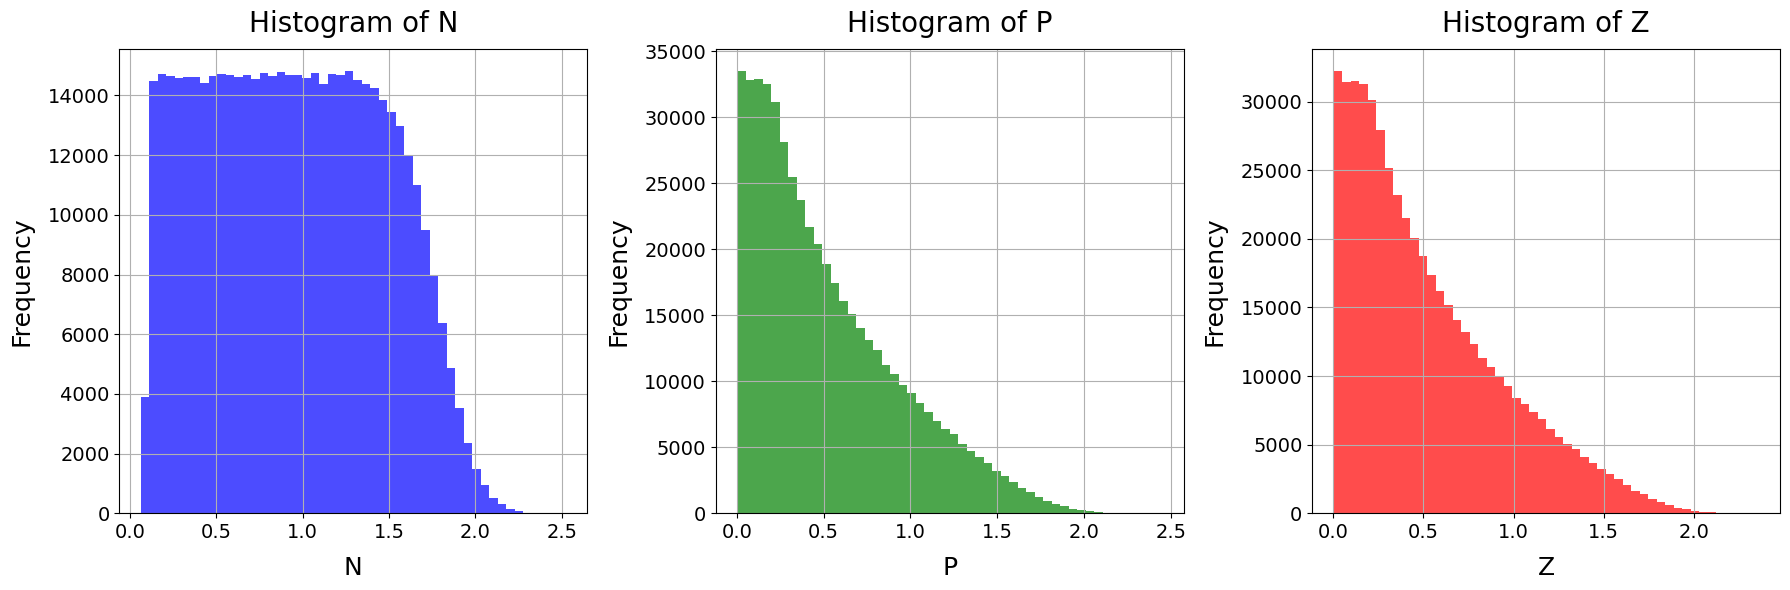

In [3]:

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# Histogram of N
axes[0].hist(npz_matrix_simplex[:, 0], bins=50, color='blue', alpha=0.7)
axes[0].set_xlabel('N', fontsize=18, labelpad=10)
axes[0].set_ylabel('Frequency', fontsize=18, labelpad=10)
axes[0].set_title('Histogram of N', fontsize=20, pad=12)
axes[0].tick_params(axis='both', labelsize=14)
axes[0].grid(True)

# Histogram of P
axes[1].hist(npz_matrix_simplex[:, 1], bins=50, color='green', alpha=0.7)
axes[1].set_xlabel('P', fontsize=18, labelpad=10)
axes[1].set_ylabel('Frequency', fontsize=18, labelpad=10)
axes[1].set_title('Histogram of P', fontsize=20, pad=12)
axes[1].tick_params(axis='both', labelsize=14)
axes[1].grid(True)

# Histogram of Z
axes[2].hist(npz_matrix_simplex[:, 2], bins=50, color='red', alpha=0.7)
axes[2].set_xlabel('Z', fontsize=18, labelpad=10)
axes[2].set_ylabel('Frequency', fontsize=18, labelpad=10)
axes[2].set_title('Histogram of Z', fontsize=20, pad=12)
axes[2].tick_params(axis='both', labelsize=14)
axes[2].grid(True)

# Tighten layout
plt.tight_layout()

# Save only as PNG
# plt.savefig("/Users/egank31/Documents/Documents - Otto/lab_meetings/figures/evolved_initial_npz_states_histograms.png", dpi=300, bbox_inches='tight')

# Show
plt.show()


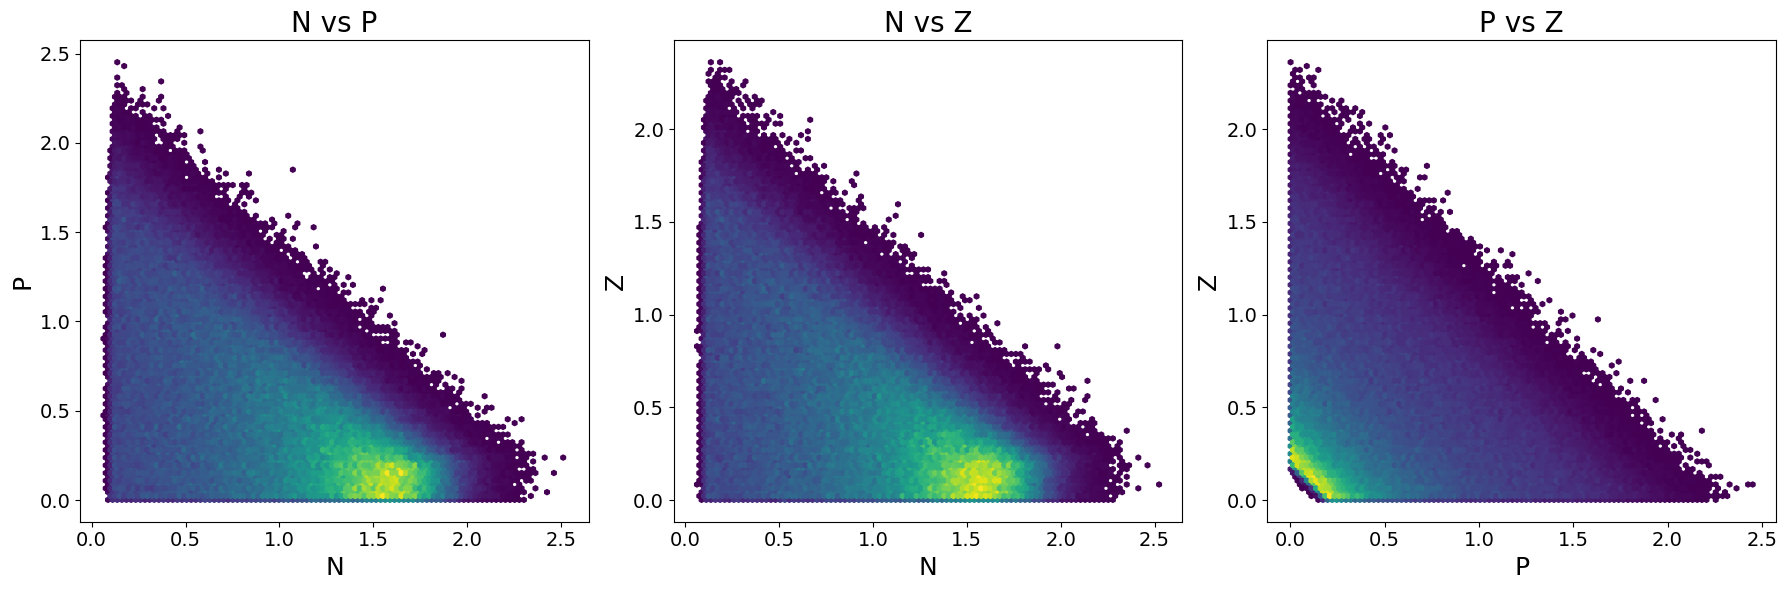

In [4]:
N = npz_matrix_simplex[:,0]
P = npz_matrix_simplex[:,1]
Z = npz_matrix_simplex[:,2]

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

font_title = 20
font_label = 18
font_tick = 14

# N vs P
axs[0].hexbin(N, P, gridsize=100, cmap='viridis', mincnt=1)
axs[0].set_xlabel("N", fontsize=font_label)
axs[0].set_ylabel("P", fontsize=font_label)
axs[0].set_title("N vs P", fontsize=font_title)
axs[0].tick_params(axis='both', labelsize=font_tick)

# N vs Z
axs[1].hexbin(N, Z, gridsize=100, cmap='viridis', mincnt=1)
axs[1].set_xlabel("N", fontsize=font_label)
axs[1].set_ylabel("Z", fontsize=font_label)
axs[1].set_title("N vs Z", fontsize=font_title)
axs[1].tick_params(axis='both', labelsize=font_tick)

# P vs Z
axs[2].hexbin(P, Z, gridsize=100, cmap='viridis', mincnt=1)
axs[2].set_xlabel("P", fontsize=font_label)
axs[2].set_ylabel("Z", fontsize=font_label)
axs[2].set_title("P vs Z", fontsize=font_title)
axs[2].tick_params(axis='both', labelsize=font_tick)

plt.tight_layout()
plt.show()



In [5]:
initial_states = pd.read_csv(
    '../data/training_validation_data/npz_training_set.csv',
    index_col=False).iloc[:,0:3]


In [6]:
# Step 1: Filter samples where N+P+Z ∈ [1.8, 2.2]
np.random.seed(1234)
row_sums = initial_states[['N0', 'P0', 'Z0']].sum(axis=1)
in_range_mask = (row_sums >= 1.85) & (row_sums <= 2.15)

# Step 2: Ensure all values are ≥ 0.1
min_value_mask = (initial_states[['N0', 'P0', 'Z0']] >= 0.1).all(axis=1)

# Step 3: Combine masks
combined_mask = in_range_mask & min_value_mask
samples_in_range = initial_states[['N0', 'P0', 'Z0']][combined_mask]

# Step 4: Sample 1,000 rows from that subset
num_test_samples = 500
sampled_df = samples_in_range.sample(n=num_test_samples, random_state=1234).reset_index(drop=True)

# Confirm
print(f"Selected {len(sampled_df)} samples in [1.8, 2.2] with all components >= 0.1")
print(f"New mean total N: {sampled_df.sum(axis=1).mean().item():.4f}")


Selected 500 samples in [1.8, 2.2] with all components >= 0.1
New mean total N: 2.0074


In [7]:
# --- NPZ Parameters ---
Vm = 2
ks = 1
m = 0.1
gamma = 0.3
Rm = 1.5
ivlev = 1
q = 0.2
phi = (Vm, ks, m, Rm, ivlev, gamma, q)

# --- Setup
start_time = 0
end_time = 4  # 4 days

# Times every 10 minutes
minutes_per_step = 10 # Could try for more minutes (30?)
dt = minutes_per_step / (60 * 24)  # minutes to days
times_disc = np.arange(start_time, end_time + dt, dt)

def run_single_rk4_full(x0, times_disc, phi):
    xt = rk4(npz_nl, x0, times_disc, None, 0, phi)
    return xt

# Evolve initial states over 7 days
xt_list = Parallel(n_jobs=4)(
    delayed(run_single_rk4_full)(x0, times_disc, phi) for x0 in sampled_df.to_numpy()
)


In [8]:
### Get values for instrument measurement range
# Stack into a single 2D array (flattening across all time and all initial conditions)
all_xt = np.vstack(xt_list)  # Shape: [n_total_timepoints_across_all_trajectories, 3]

# Get min and max per column (N, P, Z)
min_vals = np.min(all_xt, axis=0)
max_vals = np.max(all_xt, axis=0)

# Print results
print(f"Min values (N, P, Z): {min_vals}")
print(f"Max values (N, P, Z): {max_vals}")


Min values (N, P, Z): [0.0978131  0.10371603 0.10012778]
Max values (N, P, Z): [1.85877851 1.88136493 1.55579461]


In [9]:
all_times = []
all_var_N = []
all_var_P = []
all_var_Z = []

window_hr = 12
steps_per_window = int((window_hr/24) / dt)
tend_variance_data = 3 # End time (day 8)
t_var_data = np.arange(start_time, tend_variance_data + dt, dt)  # Create the array of times

for xt in xt_list:
    for i in range(len(t_var_data) - steps_per_window):
        xt_window = xt[i:i+steps_per_window+1, :]
        
        var_N = np.var(xt_window[:, 0])
        var_P = np.var(xt_window[:, 1])
        var_Z = np.var(xt_window[:, 2])
        
        all_var_N.append(var_N)
        all_var_P.append(var_P)
        all_var_Z.append(var_Z)
        
        # Track the start time of the window
        all_times.append(times_disc[i])

# Arrays of variances
var_N_array = np.array(all_var_N)
var_P_array = np.array(all_var_P)
var_Z_array = np.array(all_var_Z)


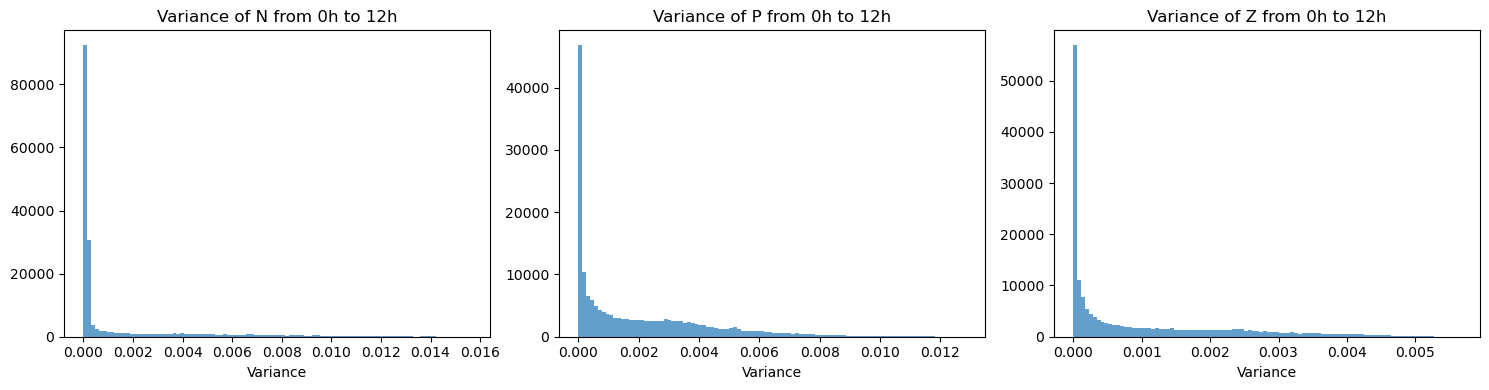

In [10]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(var_N_array, bins=100, alpha=0.7)
plt.title(f"Variance of N from 0h to 12h")
plt.xlabel("Variance")

plt.subplot(1, 3, 2)
plt.hist(var_P_array, bins=100, alpha=0.7)
plt.title(f"Variance of P from 0h to 12h")
plt.xlabel("Variance")

plt.subplot(1, 3, 3)
plt.hist(var_Z_array, bins=100, alpha=0.7)
plt.title(f"Variance of Z from 0h to 12h")
plt.xlabel("Variance")

plt.tight_layout()
plt.show()


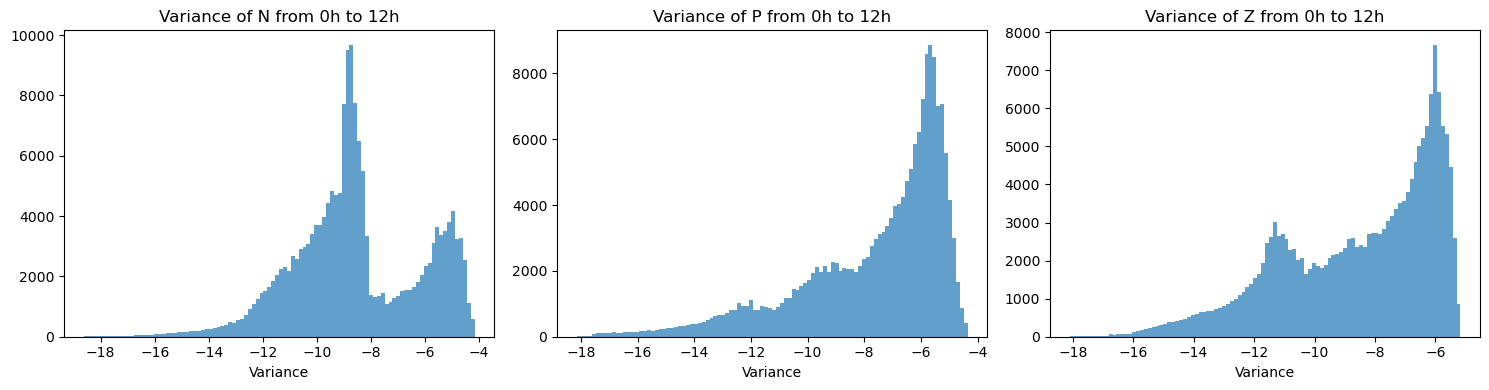

In [11]:
log_var_n = np.log(var_N_array + 1e-12).reshape(-1, 1)
log_var_p = np.log(var_P_array + 1e-12).reshape(-1, 1)
log_var_z = np.log(var_Z_array + 1e-12).reshape(-1, 1)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.hist(log_var_n, bins=100, alpha=0.7)
plt.title(f"Variance of N from 0h to 12h")
plt.xlabel("Variance")

plt.subplot(1, 3, 2)
plt.hist(log_var_p, bins=100, alpha=0.7)
plt.title(f"Variance of P from 0h to 12h")
plt.xlabel("Variance")

plt.subplot(1, 3, 3)
plt.hist(log_var_z, bins=100, alpha=0.7)
plt.title(f"Variance of Z from 0h to 12h")
plt.xlabel("Variance")

plt.tight_layout()
plt.show()



[N] GMM log-means: [-9.42307096 -5.23307962]
[N] Threshold (variance): 6.568e-04
[N] Retained 50947 / 181000 samples


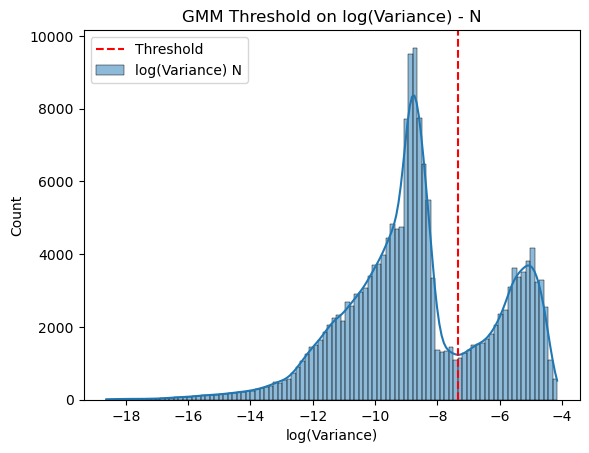


[P] GMM log-means: [-5.97069152 -9.76190061]
[P] Threshold (variance): 3.835e-04
[P] Retained 117276 / 181000 samples


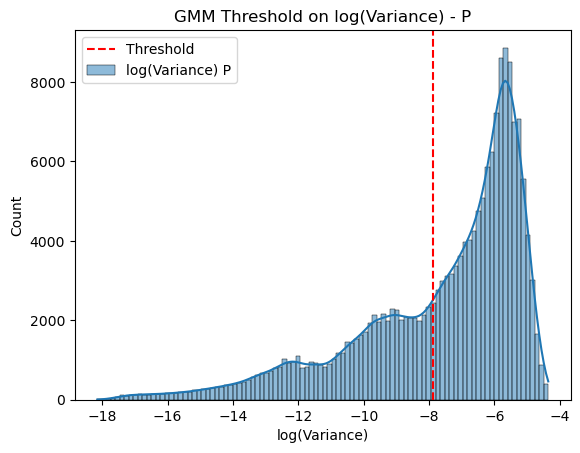


[Z] GMM log-means: [ -6.3917704  -10.21975295]
[Z] Threshold (variance): 2.471e-04
[Z] Retained 98354 / 181000 samples


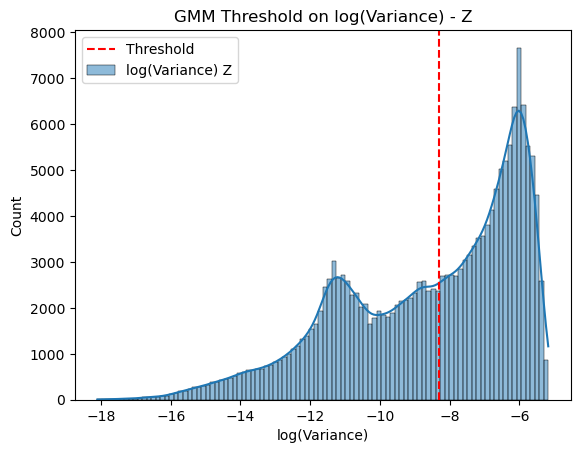

In [12]:
def gmm_threshold_variance(var_array, label="N", plot=True):
    log_var = np.log(var_array + 1e-12).reshape(-1, 1)

    # Fit GMM
    gmm = GaussianMixture(n_components=2, random_state=0)
    gmm.fit(log_var)
    means = gmm.means_.flatten()

    # Identify threshold
    noise_idx = np.argmin(means)
    signal_idx = np.argmax(means)
    log_threshold = (means[noise_idx] + means[signal_idx]) / 2
    threshold = np.exp(log_threshold)

    # Filter
    var_array_clean = var_array[var_array >= threshold]

    # Print summary
    print(f"\n[{label}] GMM log-means: {means}")
    print(f"[{label}] Threshold (variance): {threshold:.3e}")
    print(f"[{label}] Retained {len(var_array_clean)} / {len(var_array)} samples")

    # Optional plot
    if plot:
        sns.histplot(log_var.flatten(), bins=100, kde=True, label=f"log(Variance) {label}")
        plt.axvline(log_threshold, color='r', linestyle='--', label="Threshold")
        plt.title(f"GMM Threshold on log(Variance) - {label}")
        plt.xlabel("log(Variance)")
        plt.ylabel("Count")
        plt.legend()
        plt.show()

    return var_array_clean, threshold

# --- Apply to N, P, Z ---
var_N_array_clean, threshold_N = gmm_threshold_variance(var_N_array, label="N")
var_P_array_clean, threshold_P = gmm_threshold_variance(var_P_array, label="P")
var_Z_array_clean, threshold_Z = gmm_threshold_variance(var_Z_array, label="Z")


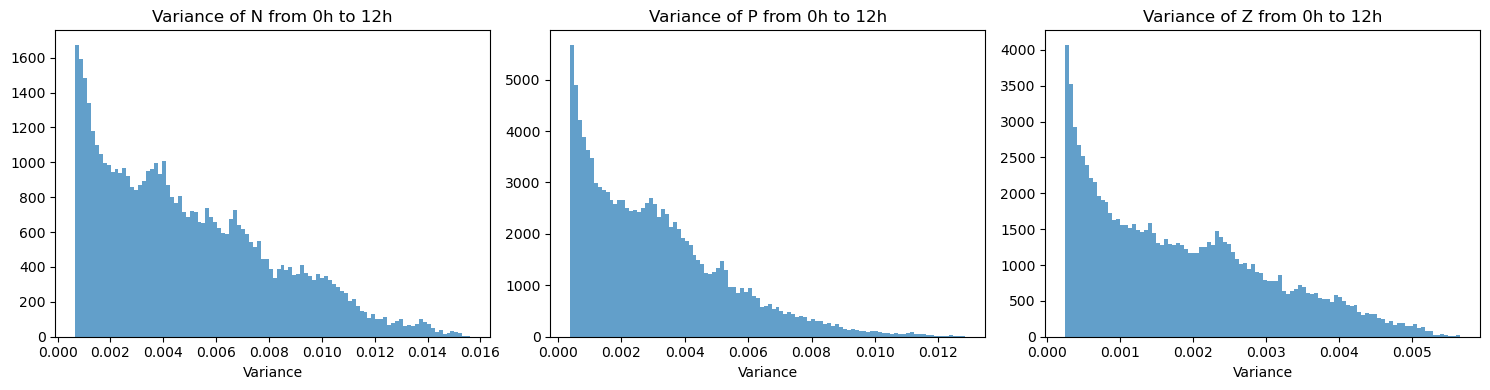

In [13]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(var_N_array_clean, bins=100, alpha=0.7)
plt.title(f"Variance of N from 0h to 12h")
plt.xlabel("Variance")

plt.subplot(1, 3, 2)
plt.hist(var_P_array_clean, bins=100, alpha=0.7)
plt.title(f"Variance of P from 0h to 12h")
plt.xlabel("Variance")

plt.subplot(1, 3, 3)
plt.hist(var_Z_array_clean, bins=100, alpha=0.7)
plt.title(f"Variance of Z from 0h to 12h")
plt.xlabel("Variance")

plt.tight_layout()
plt.show()


In [14]:
print(f"Minimum/Maximum Variances of N: {var_N_array_clean.min()}, {var_N_array_clean.max()}")
print(f"Minimum/Maximum Variances of P: {var_P_array_clean.min()}, {var_P_array_clean.max()}")
print(f"Minimum/Maximum Variances of Z: {var_Z_array_clean.min()}, {var_Z_array_clean.max()}")

Minimum/Maximum Variances of N: 0.0006568456734571354, 0.015617089313597399
Minimum/Maximum Variances of P: 0.00038345997132163245, 0.01284586527620571
Minimum/Maximum Variances of Z: 0.0002471135431407785, 0.005663699848228274


In [15]:
def lognormal_expected_value(var_array_clean, label):
    log_var = np.log(var_array_clean + 1e-12)
    mu_log = np.mean(log_var)
    sigma2_log = np.var(log_var)
    expected_val = np.exp(mu_log + 0.5 * sigma2_log)
    print(f"[{label}] Expected value (log-normal): {expected_val:.3e}")
    return expected_val

expected_var_N = lognormal_expected_value(var_N_array_clean, "N")
expected_var_P = lognormal_expected_value(var_P_array_clean, "P")
expected_var_Z = lognormal_expected_value(var_Z_array_clean, "Z")
print(expected_var_N, expected_var_P, expected_var_Z)

[N] Expected value (log-normal): 5.140e-03
[P] Expected value (log-normal): 3.221e-03
[Z] Expected value (log-normal): 1.903e-03
0.00514025148477803 0.003220575215306211 0.0019029732503254907


In [16]:
print(f"Background Uncertainty N: {expected_var_N + threshold_N}, Background Uncertainty P: {expected_var_P + threshold_P}, Background Uncertainty Z: {expected_var_Z + threshold_Z}")
print(f"Perturbation N: {np.sqrt(expected_var_N + threshold_N)}, Perturbation P: {np.sqrt(expected_var_P + threshold_P)}, Perturbation Z: {np.sqrt(expected_var_Z + threshold_Z )}")


Background Uncertainty N: 0.005797088074916317, Background Uncertainty P: 0.003604027230454881, Background Uncertainty Z: 0.0021500623212873204
Perturbation N: 0.07613861093371954, Perturbation P: 0.06003355087328153, Perturbation Z: 0.04636876450033277
